## 1. Import Libraries

In this section, the required libraries for data loading, preprocessing, model building, training, evaluation, and visualization are imported.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

## 2. Mount Google Drive and Set Dataset Path

The dataset is stored in Google Drive. This section connects Google Drive with Google Colab and sets the dataset directory path.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Set dataset path
data_dir = "/content/drive/MyDrive/dataset_animal"

##check dataset

In [4]:
import os

print(os.listdir(data_dir))

['test', 'train', 'val']


## 3. Data Preprocessing

The images are resized to 128 × 128 pixels and converted into tensors before being fed into the CNN model.

In [5]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

## 4. Load Dataset and Create DataLoaders

The dataset is loaded using ImageFolder, and DataLoaders are created for training, validation, and testing.

In [6]:
train_dataset = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
val_dataset = datasets.ImageFolder(root=data_dir + "/val", transform=transform)
test_dataset = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##check data shape

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


## 5. Device Setup

The model is trained using CPU or GPU depending on availability.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## 6. Define CNN Architecture

An improved CNN model is used with:
- Convolution layers
- Batch Normalization
- ReLU activation
- Max pooling
- Dropout
- Fully connected layers

These improvements help the model generalize better on complex datasets.

In [10]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(-1, 32 * 32 * 32)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [11]:
model = ImprovedCNN()
model.to(device)

print(model)

ImprovedCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## 7. Loss Function and Optimizer

CrossEntropyLoss is used for multi-class classification.
Adam optimizer is used for efficient training.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Training the Model

The model is trained using training data and validated using validation data.
Loss and accuracy are recorded for each epoch.

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%")
        print("-"*40)

    return train_losses, val_losses, train_accuracies, val_accuracies

## 9. Train the Model

The model is trained for 10 epochs using the training dataset.

In [14]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=10
)

Epoch [1/10]
Train Loss: 6.3614, Accuracy: 23.64%
Val Loss: 1.6261, Accuracy: 21.11%
----------------------------------------
Epoch [2/10]
Train Loss: 3.0593, Accuracy: 27.27%
Val Loss: 1.6013, Accuracy: 25.56%
----------------------------------------
Epoch [3/10]
Train Loss: 1.5068, Accuracy: 36.82%
Val Loss: 1.5643, Accuracy: 26.11%
----------------------------------------
Epoch [4/10]
Train Loss: 1.3902, Accuracy: 37.73%
Val Loss: 1.4967, Accuracy: 33.89%
----------------------------------------
Epoch [5/10]
Train Loss: 1.4457, Accuracy: 34.09%
Val Loss: 1.4474, Accuracy: 42.22%
----------------------------------------
Epoch [6/10]
Train Loss: 1.3436, Accuracy: 38.64%
Val Loss: 1.3440, Accuracy: 46.11%
----------------------------------------
Epoch [7/10]
Train Loss: 1.3034, Accuracy: 42.27%
Val Loss: 1.2491, Accuracy: 56.11%
----------------------------------------
Epoch [8/10]
Train Loss: 1.2428, Accuracy: 42.27%
Val Loss: 1.1992, Accuracy: 56.67%
---------------------------------

## 10. Training and Validation Graphs

Graphs are used to visualize model performance over epochs.

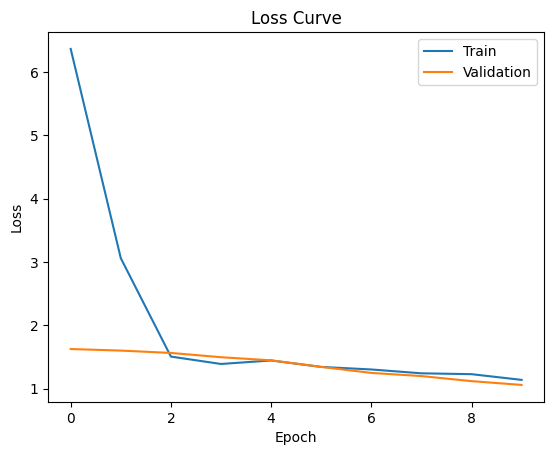

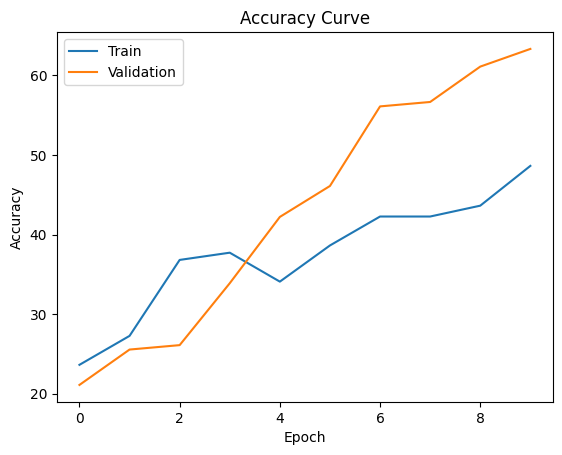

In [15]:
# Loss Graph
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Accuracy Graph
plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

## 11. Model Evaluation

The trained model is evaluated using the test dataset.
Metrics include accuracy, precision, recall, F1-score, and confusion matrix.

In [16]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [17]:
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

              precision    recall  f1-score   support

        cane       0.70      0.57      0.63        28
    elefante       0.51      0.93      0.66        28
      pecora       0.77      0.86      0.81        28
       ragno       0.92      0.79      0.85        28
  scoiattolo       0.73      0.29      0.41        28

    accuracy                           0.69       140
   macro avg       0.72      0.69      0.67       140
weighted avg       0.72      0.69      0.67       140



##Confusion Matrix

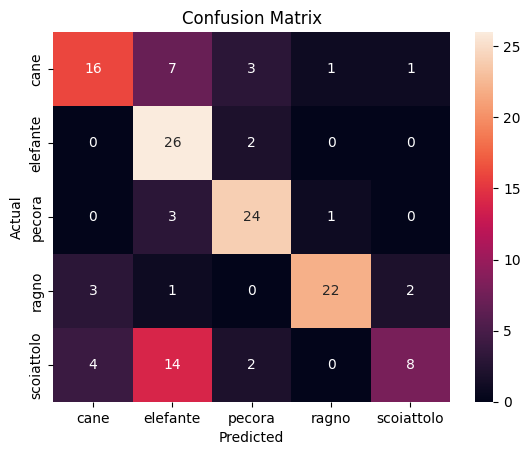

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 12. Save Model

The trained model is saved for future use.

In [19]:
torch.save(model.state_dict(), "/content/drive/MyDrive/cnn_animal_model.pth")
print("Model saved successfully")

Model saved successfully
